In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

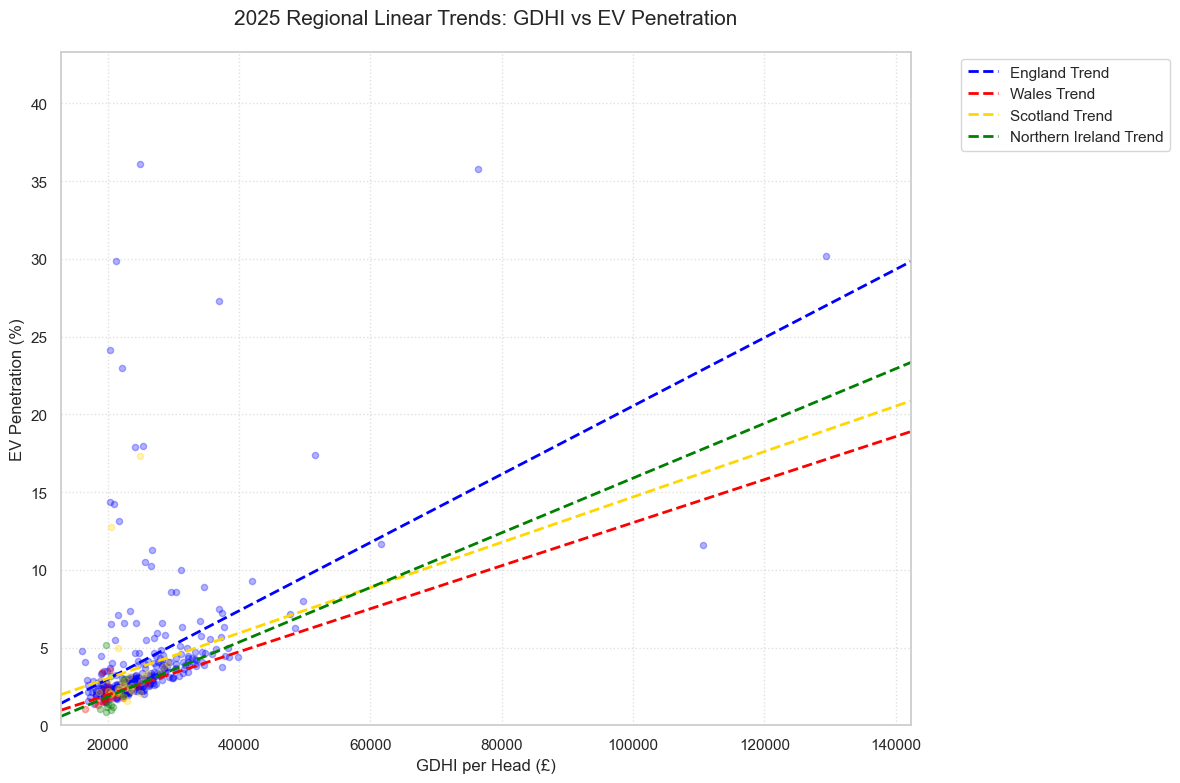

In [10]:

# 1. 读取并清洗数据
df = pd.read_csv('../Data_Clean/data/data_cleaned/Master_Panel_Data_Final.csv')
mask = (df['year'] == 2023) & (df['Geo_level'] == 'LAD')
df_2023 = df[mask].dropna(subset=['gdhi_per_head', 'ev_penetration']).copy()

# 2. 定义绘图参数
regions = {
    'E': {'color': 'blue', 'name': 'England'},
    'W': {'color': 'red', 'name': 'Wales'},
    'S': {'color': 'gold', 'name': 'Scotland'},
    'N': {'color': 'green', 'name': 'Northern Ireland'}
}

# 提前计算全局 X 轴和 Y 轴的范围
x_min_global = df_2023['gdhi_per_head'].min() * 0.8
x_max_global = df_2023['gdhi_per_head'].max() * 1.1
y_max_global = df_2023['ev_penetration'].max() * 1.2

# 设置 Seaborn 的默认主题和网格样式
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 8), dpi=100)

# 【关键】提前设置 x 轴的范围，这样 seaborn 的 truncate=False 才能据此将趋势线延伸出数据边界
plt.xlim(x_min_global, x_max_global)

for prefix, info in regions.items():
    subset = df_2023[df_2023['ONS_code'].str.startswith(prefix)]

    if not subset.empty and len(subset) > 0:
        # 使用 seaborn.regplot 一步绘制散点和线性趋势线
        sns.regplot(
            data=subset,
            x='gdhi_per_head',
            y='ev_penetration',
            ci=None,           # 不显示置信区间带，与原图保持一致
            truncate=False,    # 取消截断，使趋势线自动延伸至全局设定的 x_min 和 x_max
            color=info['color'],
            scatter_kws={'alpha': 0.3, 's': 20, 'label': f"{info['name']} Points"},
            line_kws={'linewidth': 2, 'linestyle': '--', 'label': f"{info['name']} Trend"}
        )

# 3. 图表细节优化 (完全保持一致)
plt.title('2025 Regional Linear Trends: GDHI vs EV Penetration', fontsize=15, pad=20)
plt.xlabel('GDHI per Head (£)', fontsize=12)
plt.ylabel('EV Penetration (%)', fontsize=12)

# 设置 y 轴范围
plt.ylim(0, y_max_global)

# 设置图例和网格
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)  # 覆盖seaborn默认的实线网格，保留原本的虚线风格
plt.tight_layout()
plt.savefig('Regional Linear Trends.png', dpi=300)
plt.show()